In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str

In [3]:
from langchain_community.tools import TavilySearchResults

tavily_search_tool = TavilySearchResults(max_results=2)

C:\Users\gitty\AppData\Local\Temp\ipykernel_210460\2427132948.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_search_tool = TavilySearchResults(max_results=2)


In [4]:
def web_search(state: AgentState) -> AgentState:
    """주어진 state를 기반으로 웨 검색을 수행합니다."""
    
    query = state['query']
    results = tavily_search_tool.invoke(query)
    
    return {'context': results}

In [5]:
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

generate_prompt = hub.pull('rlm/rag-prompt')
generate_llm = ChatOpenAI(model='gpt-5-mini')

def web_generate(state: AgentState) -> AgentState:
    """주어진 문맥과 질문을 기반으로 답변을 생성합니다."""
    
    context = state['context']
    query = state['query']
    
    rag_chain = generate_prompt | generate_llm | StrOutputParser()
    response = rag_chain.invoke({"context": context, "question": query})
    
    return {'answer': response}


c:\workspace\langgraph_work\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
basic_llm = ChatOpenAI(model='gpt-4o-mini')
  
def basic_generate(state: AgentState) -> AgentState:
    """사용자의 질문에 기반하여 기본 답변을 생성합니다."""
    
    query = state['query']
    llm_response = basic_llm.invoke(query)
    
    return {'answer': llm_response}

In [7]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['vector_store', 'llm', 'web_search'] = Field(
        description="The target for the query to answer"
    )
    
router_system_prompt = """ 
    사용자의 질문을 보고 'vector_store', 'llm', 'web_search'로 라우팅하는 전문가 입니다.
    'vector_store' 에는 소득세에 대한 정보가 포함되어 있습니다.
    질문이 충분히 간단하다면 'llm'을 사용합니다.
    질문에 답하기 위해 웹을 검색해야 한다면 'web_search' 을 사용합니다.
"""

router_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', router_system_prompt),
        ('human', "{query}")
    ]
)

router_llm = ChatOpenAI(model="gpt-5-mini")
structed_router_llm = router_llm.with_structured_output(Route)

def router(state: AgentState) -> Literal['vector_store', 'llm', 'web_search']:
    """ 사용자의 질문을 기반으로 적절한 경로를 결정합니다."""
    
    query = state['query']
    router_chain = router_prompt | structed_router_llm
    route = router_chain.invoke({'query': query})
    print('route: ', route.target)
    
    return route.target    

In [8]:
from income_tax_agent import graph as income_tax_subgraph

graph_builder = StateGraph(AgentState)

graph_builder.add_node('income_tax_agent', income_tax_subgraph)
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('basic_generate', basic_generate)

In [9]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        "vector_store": "income_tax_agent",
        "llm": "basic_generate",
        "web_search": "web_search"
    }
)
graph_builder.add_edge("web_search", "web_generate")
graph_builder.add_edge("web_generate", END)
graph_builder.add_edge("basic_generate", END)
graph_builder.add_edge("income_tax_agent", END)

In [10]:
graph = graph_builder.compile()

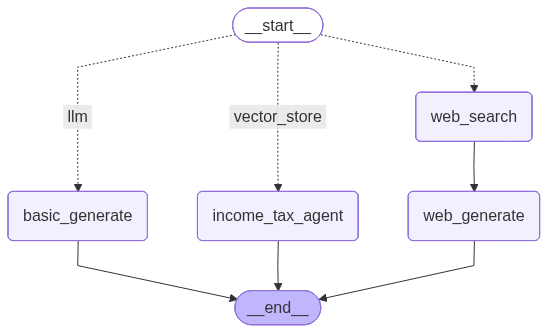

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
initial_state = {"query": "연봉 5천만원 직장인의 소득세는 얼마인가요?"}
graph.invoke(initial_state)

c:\workspace\langgraph_work\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Route(target='vector_store'), input_type=Route])
  return self.__pydantic_serializer__.to_python(


route:  vector_store
relevance: content='0' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 2004, 'total_tokens': 2008, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DIVviCYcCoa6pQdHj1oyCbHwypH4R', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='run--019ce137-2802-7de3-b513-fbb2069a805f-0' usage_metadata={'input_tokens': 2004, 'output_tokens': 4, 'total_tokens': 2008, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
rewrite: 연봉 5천만원 거주자의 소득세는 얼마인가요?
relevance: content='1' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 2073, 'total_tokens': 

{'query': '연봉 5천만원 거주자의 소득세는 얼마인가요?',
 'context': [Document(id='c38d3e74-289d-4886-94c4-f527c7bdd39e', metadata={'source': './data/tax.docx'}, page_content='제55조(세율) ①거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 “종합소득산출세액”이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\n\n| 종합소득 과세표준          | 세율                                         |\n\n|-------------------|--------------------------------------------|\n\n| 1,400만원 이하     | 과세표준의 6퍼센트                             |\n\n| 1,400만원 초과     5,000만원 이하     | 84만원 + (1,400만원을 초과하는 금액의 15퍼센트)  |\n\n| 5,000만원 초과   8,800만원 이하     | 624만원 + (5,000만원을 초과하는 금액의 24퍼센트) |\n\n| 8,800만원 초과 1억5천만원 이하    | 3,706만원 + (8,800만원을 초과하는 금액의 35퍼센트)|\n\n| 1억5천만원 초과 3억원 이하         | 3,706만원 + (1억5천만원을 초과하는 금액의 38퍼센트)|\n\n| 3억원 초과    5억원 이하         | 9,406만원 + (3억원을 초과하는 금액의 38퍼센트)   |\n\n| 5억원 초과      10억원 이하        | 1억 7,406만원 + (5억원을 초과하는 금액의 42퍼센트)|\n\n| 10억원 초과        | 3억 8,406만원 + (10억원을 초과하는

In [13]:
initial_state = {"query": "대한민국 수도는 어디인가요?"}
graph.invoke(initial_state)

c:\workspace\langgraph_work\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Route(target='llm'), input_type=Route])
  return self.__pydantic_serializer__.to_python(


route:  llm


{'query': '대한민국 수도는 어디인가요?',
 'answer': AIMessage(content='대한민국의 수도는 서울입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 15, 'total_tokens': 23, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a1681c17ec', 'id': 'chatcmpl-DIVvr3BkwfC8pNmKMviB2M0sF6PKQ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--019ce137-4c54-7a31-8d55-076ee187fd70-0', usage_metadata={'input_tokens': 15, 'output_tokens': 8, 'total_tokens': 23, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}

In [14]:
initial_state = {"query": "정부과천청사역 주변 맛집을 추천해 주세요.?"}
graph.invoke(initial_state)

c:\workspace\langgraph_work\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Route(target='web_search'), input_type=Route])
  return self.__pydantic_serializer__.to_python(


route:  web_search


{'query': '정부과천청사역 주변 맛집을 추천해 주세요.?',
 'context': [{'title': '정부과천청사 근처 맛집 지금 가볼 만한 TOP 4 - 식신',
   'url': 'https://www.siksinhot.com/theme/magazine/7168',
   'content': "편의: 상가 주차 가능, 테이블 간격 넓은 좌석, 에스컬레이터 인접\n\n특징: 현지 스타일 소스와 허브 제공, 맑고 담백한 육수 계열 쌀국수\n\n### 4. 고릴라 — 항정살 '모서리'와 무쇠철판 구이로 알려진 오랜 고기집\n\n고릴라\n\n고릴라\n\n고릴라 바로가기▶\n\n#### 자주 묻는 질문\n\nQ. 어떤 부위를 많이 주문하나요?\n\nA. 항정살 계열인 '모서리' 주문이 잦고, 삼겹·목살·가브리살·양념갈비·소갈비살 등 구이 선택지가 있습니다.\n\nQ. 점심 식사도 가능한가요?\n\nA. 김치찌개·불고기·해물순두부·청국장·된장찌개 등 점심 구성이 운영됩니다. 상세 구성과 가격은 방문일 기준 현장 확인을 권합니다.\n\n위치: 경기도 과천시 새술막길 38 중앙빌딩 1층(정부과천청사역 11번 출구 도보 약 5분)\n\n영업시간: 매일 11:30~22:00, 브레이크타임 14:00~17:00(주말 제외)\n\n메뉴: 모서리(항정살), 삼겹·목살, 가브리살, 양념갈비, 소갈비살, 된장찌개·계란찜·냉면\n\n편의: 2층 단체석 운영, 공영주차장 인접, 드럼통 테이블·환기설비, 좌석 수납공간\n\n특징: 무쇠철판으로 굽는 담백한 식감, 레트로 감성의 숯불 고기집 분위기\n\n## 비교 & 선택 팁\n\n1. 보양식·활해산물 기반 국물요리 → 과천해신탕\n\n2. 역 출구 앞 고기와 룸이 필요한 소규모 회식 → 고굽진 과천본점\n\n3. 베트남식 반쎄오·공심채볶음으로 색다른 저녁 → 몬안베띠 과천힐스테이트점\n\n4. 항정살 특화·단체석이 필요한 캐주얼 회식 → 고릴라\n\n더 많은 '정부과천청사 근처 맛집' 정보는 아래에서 확인하세요.\n\n### 고릴라